In [1]:
!pip install langgraph langchain langchain-google-genai google-generativeai


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 2.5 MB/s eta 0:00:00


In [2]:
from typing import TypedDict,Literal
from langgraph.graph import StateGraph,START,END
from langchain_google_genai import ChatGoogleGenerativeAI

In [3]:
from langchain_core import tools

In [5]:
from IPython.display import Image

In [6]:
import os
os.environ["GOOGLE_API_KEY"]="xyz"

In [7]:
llm=ChatGoogleGenerativeAI(
    model="gemini-2.5-flash"
)

In [8]:
class HealthcareState(TypedDict):
    patient_name: str
    age: int
    fever: float
    oxygen_level: int
    heart_rate: int
    symptom_duration: int
    existing_conditions: str

    severity_level:str
    priority:str
    consultation:str

In [9]:
def syptom_severity(state:HealthcareState):
    fever = state["fever"]
    oxygen = state["oxygen_level"]
    heart_rate = state["heart_rate"]
    duration = state["symptom_duration"]

    # Critical Condition
    if oxygen < 90 or heart_rate > 130 or fever > 104:
        state["severity_level"] = "CRITICAL"

    # Moderate Condition
    elif fever >= 101 or duration >= 5:
        state["severity_level"] = "MODERATE"

    # Stable Condition
    else:
        state["severity_level"] = "STABLE"

    print("SEVERITY LEVEL:", state["severity_level"])

    return state



In [11]:
def medical_priority(state:HealthcareState):
    prompt=f"""
    You are a hospital triage assistant.
    Analyze the patient details.
    Severity level: {state["severity_level"]}
    Patient Name: {state["patient_name"]}
    Age: {state["age"]}
    Existing Conditions:{state["existing_conditions"]}

    Rules:
    CRITICAL_PATIENTS-EMERGENCY
    Elderly patients with existing conditions may need PRIORITY_CONSULTATION
    Stable patients-REGULAR_CONSULTATION

    Return only the category
    """
    response=llm.invoke(prompt)
    state["priority"]=response.content.strip()
    return state



In [12]:
def consultaion_assignment(state:HealthcareState):
    priority=state["priority"]
    if priority=="EMERGENCY_CONSULTATION":
        state["consultation"]="ICU/ER"
    elif priority=="PRIORITY_CONSULTATION":
        state["consultation"]="Specialist Doctor"
    else:
        state["REGULAR CONSULTATION"]="General Physician"
    return state

In [16]:
graph=StateGraph(HealthcareState)
graph.add_node("Symptom Severity",syptom_severity)
graph.add_node("Medical_priority",medical_priority)
graph.add_node("Consultation Assignment",consultaion_assignment)
graph.add_edge(START,"Symptom Severity")
graph.add_edge("Symptom Severity","Medical_priority")
graph.add_edge("Medical_priority","Consultation Assignment")
graph.add_edge("Consultation Assignment",END)
workflow=graph.compile()

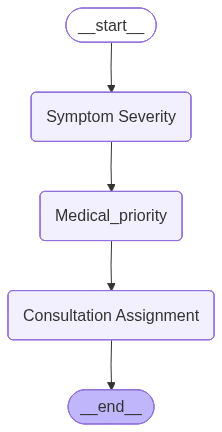

In [17]:
workflow

In [18]:
input_data = {
    "patient_name": "Ravi",
    "age": 68,
    "fever": 103,
    "oxygen_level": 88,
    "heart_rate": 135,
    "symptom_duration": 6,
    "existing_conditions": "Diabetes, Hypertension"
}


In [22]:
print(workflow.invoke(input_data))


SEVERITY LEVEL: CRITICAL
{'patient_name': 'Ravi', 'age': 68, 'fever': 103, 'oxygen_level': 88, 'heart_rate': 135, 'symptom_duration': 6, 'existing_conditions': 'Diabetes, Hypertension', 'severity_level': 'CRITICAL', 'priority': 'EMERGENCY'}


In [23]:
data = {
    "patient_name": "Suresh",
    "age": 62,
    "fever": 101,
    "oxygen_level": 95,
    "heart_rate": 92,
    "symptom_duration": 5,
    "existing_conditions": "Diabetes"
}

In [24]:
print(workflow.invoke(data))

SEVERITY LEVEL: MODERATE
{'patient_name': 'Suresh', 'age': 62, 'fever': 101, 'oxygen_level': 95, 'heart_rate': 92, 'symptom_duration': 5, 'existing_conditions': 'Diabetes', 'severity_level': 'MODERATE', 'priority': 'PRIORITY_CONSULTATION', 'consultation': 'Specialist Doctor'}
